In [1]:
# Breadth vs Depth in Neural Networks
# Comparing wide and deep ANN architectures by parameter count

import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Function to count trainable parameters
# --------------------------------------------------

def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


# --------------------------------------------------
# 2. Function to build ANN models
# --------------------------------------------------

def build_model(layer_sizes):
    layers = []

    for i in range(len(layer_sizes) - 1):

        layers.append(
            nn.Linear(layer_sizes[i], layer_sizes[i + 1])
        )

        if i < len(layer_sizes) - 2:
            layers.append(nn.ReLU())

    return nn.Sequential(*layers)


# --------------------------------------------------
# 3. Define different architectures
# --------------------------------------------------

architectures = {
    "Shallow Small": [4, 16, 3],
    "Shallow Wide": [4, 128, 3],
    "Moderately Deep": [4, 64, 32, 3],
    "Deep Narrow": [4, 32, 16, 8, 3],
    "Deep Wide": [4, 128, 64, 32, 3],
    "Very Deep Narrow": [4, 32, 32, 16, 16, 8, 3]
}


# --------------------------------------------------
# 4. Build models and count parameters
# --------------------------------------------------

results = []

for name, layer_sizes in architectures.items():

    model = build_model(layer_sizes)

    total_parameters = count_parameters(model)

    results.append({
        "Architecture": name,
        "Layer Sizes": " → ".join(map(str, layer_sizes)),
        "Number of Layers": len(layer_sizes) - 1,
        "Trainable Parameters": total_parameters
    })

    print()
    print(name)
    print(model)
    print(f"Trainable Parameters: {total_parameters}")


# --------------------------------------------------
# 5. Display results as a table
# --------------------------------------------------

results_df = pd.DataFrame(results)

results_df


Shallow Small
Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=3, bias=True)
)
Trainable Parameters: 131

Shallow Wide
Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=3, bias=True)
)
Trainable Parameters: 1027

Moderately Deep
Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=3, bias=True)
)
Trainable Parameters: 2499

Deep Narrow
Sequential(
  (0): Linear(in_features=4, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=8, bias=True)
  (5): ReLU()
  (6): Linear(in_features=8, out_features=3, bias=True)
)
Trainable Parameters: 851

Deep Wide
Sequential(
  (0): Linear(in_features=4,

,Architecture,Layer Sizes,Number of Layers,Trainable Parameters
0,Shallow Small,4 → 16 → 3,2,131
1,Shallow Wide,4 → 128 → 3,2,1027
2,Moderately Deep,4 → 64 → 32 → 3,3,2499
3,Deep Narrow,4 → 32 → 16 → 8 → 3,4,851
4,Deep Wide,4 → 128 → 64 → 32 → 3,4,11075
5,Very Deep Narrow,4 → 32 → 32 → 16 → 16 → 8 → 3,6,2179


In [2]:
results_df.sort_values(
    by="Trainable Parameters",
    ascending=True
)

,Architecture,Layer Sizes,Number of Layers,Trainable Parameters
0,Shallow Small,4 → 16 → 3,2,131
3,Deep Narrow,4 → 32 → 16 → 8 → 3,4,851
1,Shallow Wide,4 → 128 → 3,2,1027
5,Very Deep Narrow,4 → 32 → 32 → 16 → 16 → 8 → 3,6,2179
2,Moderately Deep,4 → 64 → 32 → 3,3,2499
4,Deep Wide,4 → 128 → 64 → 32 → 3,4,11075


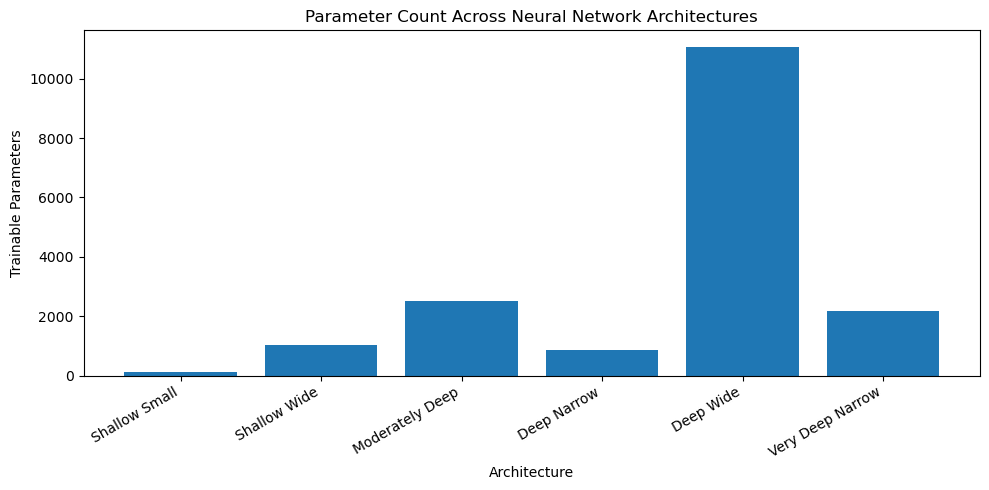

In [3]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Architecture"],
    results_df["Trainable Parameters"]
)

plt.xlabel("Architecture")
plt.ylabel("Trainable Parameters")
plt.title("Parameter Count Across Neural Network Architectures")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [4]:
# --------------------------------------------------
# 6. Compare breadth and depth explicitly
# --------------------------------------------------

comparison_architectures = {
    "Wide Shallow": [4, 128, 3],
    "Deep Narrow": [4, 32, 16, 8, 3],
    "Deep Wide": [4, 128, 64, 32, 3]
}

comparison_results = []

for name, layer_sizes in comparison_architectures.items():

    model = build_model(layer_sizes)

    comparison_results.append({
        "Architecture": name,
        "Layer Sizes": " → ".join(map(str, layer_sizes)),
        "Hidden Layers": len(layer_sizes) - 2,
        "Trainable Parameters": count_parameters(model)
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Architecture,Layer Sizes,Hidden Layers,Trainable Parameters
0,Wide Shallow,4 → 128 → 3,1,1027
1,Deep Narrow,4 → 32 → 16 → 8 → 3,3,851
2,Deep Wide,4 → 128 → 64 → 32 → 3,3,11075


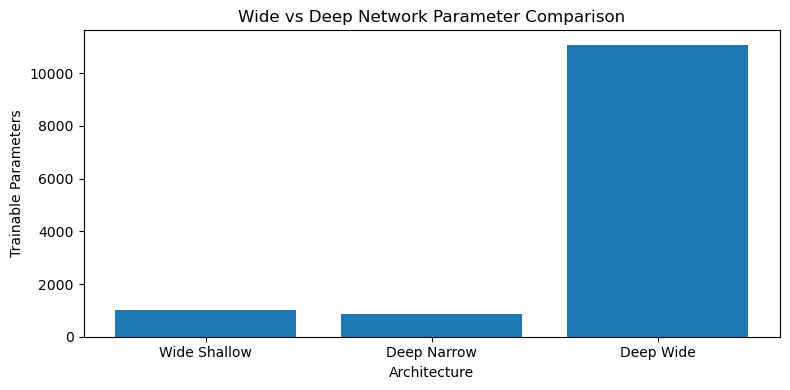

In [5]:
plt.figure(figsize=(8, 4))

plt.bar(
    comparison_df["Architecture"],
    comparison_df["Trainable Parameters"]
)

plt.xlabel("Architecture")
plt.ylabel("Trainable Parameters")
plt.title("Wide vs Deep Network Parameter Comparison")

plt.tight_layout()
plt.show()

In [6]:
# --------------------------------------------------
# 7. Manual parameter calculation example
# --------------------------------------------------

# Architecture: [4, 16, 3]
# Layer 1: input 4 -> hidden 16
# Weights = 4 * 16
# Biases  = 16
#
# Layer 2: hidden 16 -> output 3
# Weights = 16 * 3
# Biases  = 3

manual_count = (4 * 16 + 16) + (16 * 3 + 3)

print("Manual parameter count:", manual_count)

model = build_model([4, 16, 3])

print("PyTorch parameter count:", count_parameters(model))

Manual parameter count: 131
PyTorch parameter count: 131


## What This Notebook Demonstrates

This notebook shows that neural network size is determined not only by how many layers a model has, but also by how many neurons each layer contains. A shallow but wide network may contain more trainable parameters than a deeper but narrower network.

For example:

Wide Shallow: 4 → 128 → 3 <br>
Deep Narrow : 4 → 32 → 16 → 8 → 3

Even though the second model has more layers, it may not necessarily have more parameters. This helps readers understand the trade-off between breadth, depth, capacity, and computational cost.